# Probabilistic Cellular Automata

In [15]:
import itertools

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jaxtyping import Array, Float, Int
from torx import AbstractMultiBinaryPGate, DiscretePCircuit, PCopy, SampleSimulator

## 1D cellular automata

At each time step, the state of every cell is updated based on the cell's current state and the states of the two neighbouring cells. The update rule for the Rule 110 automaton is:

|Current pattern|111|110|101|100|011|010|001|000|
|:---------------|---|---|---|---|---|---|---|---|
|New pattern    |101|110|111|100|011|010|011|000|

In the above table, the middle cell is the one that is being updated.

We can implement these automata in `torx`. Each cell is encoded as a pbit whose value corresponds to the current state of the cell. The update rule can be implemented using multi-controlled NOT gates, controlled on the current value of the cell and its neighbours. For example, the update $001\to 011$ for a single cell can be done with a NOT gate controlled on 0 for the first pbit, 0 for the second, and 1 for the third.

In practice, since all cell states are updated simultaneously, we also need an ancillary register to store the new states before updating the cells.

It's easy to extend the deterministic rule above to a probabilistic rule by replacing the multi-controlled NOT gates with multi-controlled PNOT gates. In this case, the update rule is applied with some probability $p$, and otherwise does nothing.

First write a utility function to construct the classes for the multi-controlled PNOT gates, since these aren't available natively in `torx`:

In [16]:
def get_switches_1d():
    switches = {}

    id_op = jnp.array(list(itertools.product([0, 1], repeat=4)))

    def create_class(i):
        class _Switch(AbstractMultiBinaryPGate):
            theta: Float[Array, ""]
            sites: list[int]

            @property
            def num_branches(self) -> int:
                return 2

            @property
            def branches(self) -> Int[Array, "2 16 4"]:
                # branch 0: identity (do nothing)
                # branch 1: flip the last pbit conditioned on the first 3 pbits
                op_action = id_op.at[2 * i, 3].set(1)
                op_action = op_action.at[2 * i + 1, 3].set(0)
                return jnp.stack([id_op, op_action])

            def get_matrix(self) -> Float[Array, "16 16"]:
                raise NotImplementedError

        _Switch.__name__ = f"_Switch_{i}"
        _Switch.__qualname__ = f"_Switch_{i}"
        return _Switch

    for i in range(8):
        switches[i] = create_class(i)

    return switches

Next, write a function to create a circuit that updates the state of a cellular automaton. This circuit takes 8 parameters which represent the probability of applying the update rule for each of the 8 state combinations:

In [17]:
def get_nca_circuit_1d(num_pbits, thetas=None):
    switches = get_switches_1d()
    gates = []

    # copy all values from the state register to work register
    for i in range(num_pbits):
        gates.append(PCopy(jnp.array(1000.0), [i, i + num_pbits]))

    # update the cell states using the work register
    # assume open boundary conditions
    for i in range(1, num_pbits - 1):
        for j, switch in switches.items():
            gates.append(switch(thetas[j], [i - 1, i, i + 1, i + num_pbits]))

    # copy the updated states back to the main register
    for i in range(num_pbits):
        gates.append(PCopy(jnp.array(1000.0), [i + num_pbits, i]))

    return DiscretePCircuit(gates)

To demonstrate this circuit, we create two update rules: one that applies Rule 110 deterministically and the other that applies Rule 110 with probability $99\%$, and otherwise does nothing:

In [18]:
num_pbits = 100

# rule 110 parameters

thetas_deterministic = jnp.inf * jnp.array([-1.0, 1, -1, -1, -1, 1, -1, 1])
circuit_deterministic = get_nca_circuit_1d(num_pbits, thetas=thetas_deterministic)

# sigmoid(5) is approximately 0.99
thetas_probabilistic = 4 * jnp.array([-1.0, 1, -1, -1, -1, 1, -1, 1])
circuit_probabilistic = get_nca_circuit_1d(num_pbits, thetas=thetas_probabilistic)

Run a 300-step simulation for each of the automata:

In [19]:
sim = SampleSimulator(num_samples=1)
built_circuit_deterministic = sim.build_circuit(circuit_deterministic)

curr_state = jax.random.randint(
    jax.random.key(101), shape=(2 * num_pbits,), minval=0, maxval=2
)
states_deterministic = [curr_state]

num_steps = 300
key = jax.random.key(1000)
sample_fn = eqx.filter_jit(sim.sample)

for steps in range(num_steps):
    key, subkey = jax.random.split(key)
    curr_state = sample_fn(built_circuit_deterministic, curr_state, subkey)[0]
    states_deterministic.append(curr_state)

states_deterministic = jnp.stack(states_deterministic)[:, :num_pbits]

In [20]:
sim = SampleSimulator(num_samples=1)
built_circuit_probabilistic = sim.build_circuit(circuit_probabilistic)

curr_state = jax.random.randint(
    jax.random.key(101), shape=(2 * num_pbits,), minval=0, maxval=2
)
states_probabilistic = [curr_state]

num_steps = 300
key = jax.random.key(1000)
sample_fn = eqx.filter_jit(sim.sample)

for steps in range(num_steps):
    key, subkey = jax.random.split(key)
    curr_state = sample_fn(built_circuit_probabilistic, curr_state, subkey)[0]
    states_probabilistic.append(curr_state)

states_probabilistic = jnp.stack(states_probabilistic)[:, :num_pbits]

Show the results of the simulation:

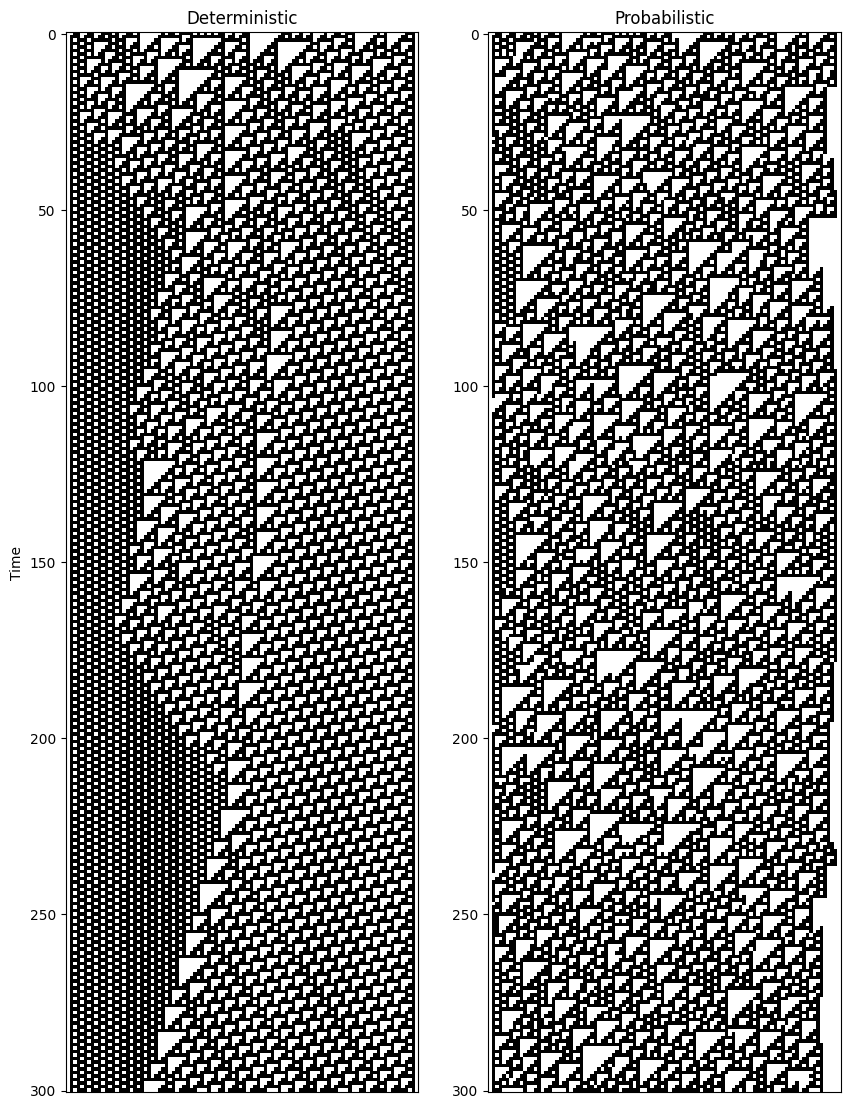

In [21]:
def plot_evolution(states_det, states_prob):
    # states: (time, num_pbits)

    fig, axs = plt.subplots(
        1, 2, figsize=(states_det.shape[1] / 10, states_det.shape[0] / 5)
    )

    axs[0].imshow(1 - states_det, cmap="gray", vmin=0, vmax=1)
    axs[1].imshow(1 - states_prob, cmap="gray", vmin=0, vmax=1)
    axs[0].set_ylabel("Time")
    axs[0].set_xticks([])
    axs[1].set_xticks([])

    axs[0].set_title("Deterministic")
    axs[1].set_title("Probabilistic")

    plt.show()


plot_evolution(states_deterministic, states_probabilistic)

Since we used open boundary conditions for the 1D grid world, it only makes sense to run the automata for time less than or equal to the length of the grid. However, we run the simulation for a longer time to show that, in the deterministic case any interesting structures eventually fizzle out of existence, but in the probabilistic case the structures continue to appear.